In [1]:
using Pkg
Pkg.activate(ENV["PYTHON_JULIAPKG_PROJECT"])
using ReactionMechanismSimulator

  Activating project at `~/miniforge3/envs/rmg_env3/julia_env`
Precompiling packages...
   1809.2 ms  ? DomainSets
   2664.9 ms  ? Symbolics
   6791.8 ms  ? ModelingToolkit
  25872.3 ms  ? SciMLSensitivity
Info Given ReactionMechanismSimulator was explicitly requested, output will be shown live 
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
   2102.0 ms  ? ReactionMechanismSimulator
[ Info: Precompiling ReactionMechanismSimulator [c2d78dd2-25c4-5b79-bebc-be6c69dd440f]
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
[ Info: Skipping precompilation since __precompile__(false). Importing ReactionMechanismSimulator [c2d78dd2-25c4-5b79-bebc-be6c69dd440f].
┌ Warning: Replacing docs for `ReactionMechanismSimulator.getpairs :: Tuple{T} where T<:ReactionMechanismSimulator.AbstractReaction` in module `ReactionMechanismSimulator`
└

In [2]:
using PythonPlot
using DifferentialEquations
using Sundials
using SciMLBase
using QuadGK
using DataFrames
using Statistics

function run_co2_reduction_simulation(params::Vector{Float64})
	try
		CO2_M = params[1]
		pH = params[2]
		surface_phi = params[3]
		layer_thickness = params[4]
		CO2_X_init = params[5]

		if CO2_X_init < 0.0 || CO2_X_init > 1.0
        return 1e-15
    end
    if layer_thickness <= 0.0
        return 1e-15
    end

		rms_file = "/home/danieltori/CO2_RR_RMG/CO2_Reduction_Ag/Ag_C2_042925.rms"

		outdict = readinput(rms_file)
		boundarylayerspcs = outdict["gas"]["Species"]
		boundarylayerrxns = outdict["gas"]["Reactions"]
		surfspcs = outdict["surface"]["Species"]
		surfrxns = outdict["surface"]["Reactions"]
		interfacerxns = outdict[Set(["surface", "gas"])]["Reactions"]
		solv = outdict["Solvents"][1]

		sitedensity = 2.292e-5; #Ag111
		boundarylayer = IdealDiluteSolution(boundarylayerspcs, boundarylayerrxns, solv,
			name = "boundarylayeruid", diffusionlimited = true)
		surf = IdealSurface(surfspcs, surfrxns, sitedensity, name = "surface")


    C_proton = 10.0^(-pH) * 1e3         # mol/m³
    C_co2    = CO2_M * 1e3              # mol/m³
    C_default = 1e-12
    V_res   = 1e3
    AVratio = 36.0
    A_surf  = V_res * AVratio
    V_bl    = A_surf * layer_thickness
    sites   = sitedensity * A_surf
		

		initialcondsboundarylayer = Dict([
			"proton" => C_proton * V_bl,
			"CO2" => C_co2 * V_bl,
			"V" => V_bl,
			"T" => 300,
			"Phi" => 0.0,
			"d" => 0.0,
		])

		initialcondsreservoir = Dict([
			"proton" => C_proton,
			"CO2" => C_co2,
			"V" => V_res,
			"T" => 300,
		])

		initialcondssurf = Dict([
			"CO2X" => CO2_X_init * sites,
			"vacantX" => (1 - CO2_X_init) * sites,
			"A" => A_surf,
			"T" => 300,
			"Phi" => surface_phi,
		])

		domainboundarylayer, y0boundarylayer, pboundarylayer = ConstantTVDomain(
			phase = boundarylayer, initialconds = initialcondsboundarylayer)
		domaincat, y0cat, pcat = ConstantTAPhiDomain(
			phase = surf, initialconds = initialcondssurf)

		inter, pinter = ReactiveInternalInterfaceConstantTPhi(
			domainboundarylayer, domaincat, interfacerxns, 298.15, A_surf)
		diffusionlayer = ConstantReservoirDiffusion(
			domainboundarylayer, initialcondsreservoir, A_surf, layer_thickness)
		interfaces = [inter, diffusionlayer]

		@time react, y0, p = Reactor((domainboundarylayer, domaincat),
			(y0boundarylayer, y0cat),
			(0.0, 1e3),
			interfaces,
			(pboundarylayer, pcat, pinter))

		@time sol = solve(react.ode, Sundials.CVODE_BDF(), abstol = 1e-20, reltol = 1e-8)

		if sol.retcode != :Success
			return 1e-15
		end

		ssys = SystemSimulation(sol, (domainboundarylayer, domaincat), interfaces, p)

		# EXACT CALCULATION METHOD
		analysis_time = 100
		OCO_rate = abs(sum(rops(ssys, "O=CO", analysis_time)))
		
		return OCO_rate

	catch e
		return 1e-15
	end
end



run_co2_reduction_simulation (generic function with 1 method)

In [3]:
using GlobalSensitivity

bounds = [
    [1e-5,   1e-2],     # CO2 concentration
    [5.0,    9.0],      # pH
    [-0.714, -0.514],   # potential
    [1e-6,   1e-4],     # layer thickness
    [0.5,    0.9]       # CO2X surface coverage
]

param_names = ["CO₂_conc", "pH", "potential", "layer_thickness", "CO2X_init"]

morris_method = Morris(
    p_steps = fill(4, 5),        
    relative_scale = true, 
    num_trajectory = 50,
    total_num_trajectory = 50,
    len_design_mat = 10          #
)

println("Running Morris Global Sensitivity Analysis...")

morris_result = gsa(
    run_co2_reduction_simulation,
    morris_method,
    bounds;
    batch = false
)


Running Morris Global Sensitivity Analysis...


[05:27:49] WARNING: not removing hydrogen atom without neighbors
[05:27:49] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  7.470363 seconds (12.31 M allocations: 799.132 MiB, 7.30% gc time, 97.51% compilation time: <1% of which was recompilation)
  5.322340 seconds (5.12 M allocations: 556.437 MiB, 29.13% gc time, 77.49% compilation time)


[05:28:25] WARNING: not removing hydrogen atom without neighbors
[05:28:25] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.005773 seconds (8.46 k allocations: 7.893 MiB)
  0.296729 seconds (428.57 k allocations: 313.186 MiB, 4.46% gc time)


...

  0.004134 seconds (8.46 k allocations: 7.893 MiB)
  0.205403 seconds (351.49 k allocations: 275.805 MiB, 3.31% gc time)


[05:30:51] WARNING: not removing hydrogen atom without neighbors
[05:30:51] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004199 seconds (8.46 k allocations: 7.882 MiB)
  0.224299 seconds (312.42 k allocations: 238.698 MiB, 12.44% gc time)


[05:30:56] WARNING: not removing hydrogen atom without neighbors
[05:30:56] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

GlobalSensitivity.MorrisResult{Matrix{Float64}, Vector{Any}}([166117.29929888863 175.22118841234715 … 1.0574290444473565e8 0.3303071038688866], [166146.8405971278 175.9133227104111 … 1.0578128150847559e8 0.5089832573012443], [9.589455185878293e10 1.1832655488435198e6 … 5.198275217178523e17 1.4105489734469598], Any[[333.60574442449143, 0.0004475280632164797, 15.13806688521921, 463591.35533531394, 146.35805851651855, 301.4527690839822, 66.38441305168233, 443740.59037047374, 686563.6090077661, -300.19179278894103  …  -11.880430040462729, -11.880430040462729, 296.90672294254676, 148588.05743072196, -124.33234121005661, -30.196596199017883, 301.7188698688081, 180023.3311712007, 180023.3311712007, 180023.3311712007], [-0.24324010088371995, -0.2432126557146252, -0.2432126557146252, 7126.045955685887, 7126.045955685887, -0.23674334735995087, -0.23674334735995087, -0.23674334735995087, -0.2367031491646467, 0.8063917787441577  …  -0.623201361400776, -0.09014554337916153, 0.5304954579390632, -0.0

In [4]:
param_names = ["CO₂_conc", "pH", "potential", "layer_thickness", "CO2X_init"]

# Extract Morris outputs
Mu      = morris_result.means[1, :]        # signed mean effects
Mu_star = morris_result.means_star[1, :]   # absolute mean effects
Sigma  = morris_result.variances[1, :]    # variance

println("μ values = ", Mu)
println("μ* values = ", Mu_star)
println("σ² values = ", Sigma)


μ values = [166117.29929888863, 175.22118841234715, -9.531621200772605, 1.0574290444473565e8, 0.3303071038688866]
μ* values = [166146.8405971278, 175.9133227104111, 10.68450303315068, 1.0578128150847559e8, 0.5089832573012443]
σ² values = [9.589455185878293e10, 1.1832655488435198e6, 48.76961396120013, 5.198275217178523e17, 1.4105489734469598]


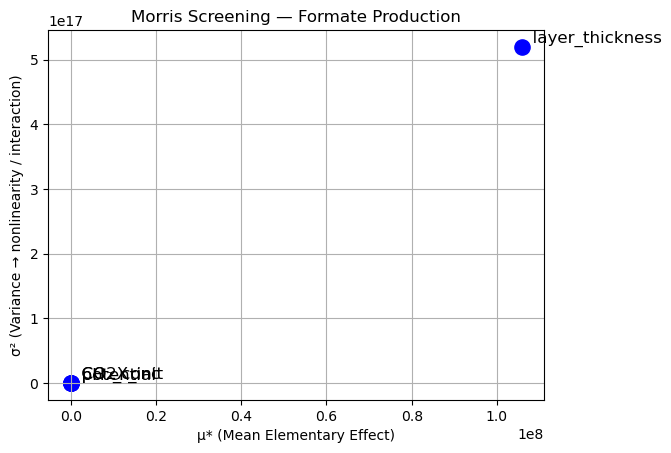

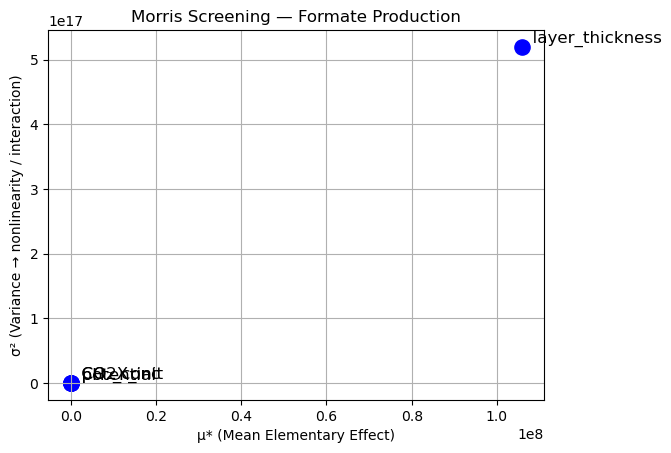

In [12]:
# Extract Morris results  (formate / O=CO)
xs = morris_result.means_star[1, :]   # absolute mean effects
ys = morris_result.variances[1, :]    # variance


param_labels = ["CO₂_conc", "pH", "potential", "layer_thickness", "CO2X_init"]   

# SCATTER PLOT
clf()
scatter(xs, ys, color="blue", s=120)

# LABEL EACH POINT
for i in 1:length(xs)
    text(xs[i], ys[i], "  $(param_labels[i])",
         fontsize=12, ha="left", va="bottom")
end

xlabel("μ* (Mean Elementary Effect)")
ylabel("σ² (Variance → nonlinearity / interaction)")
title("Morris Screening — Formate Production")
grid(true)
gcf()


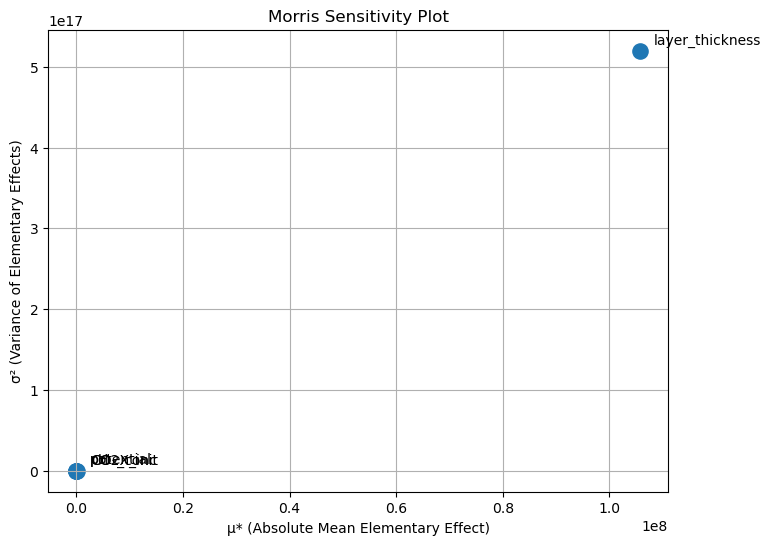

In [14]:
# MORRIS  sensitivity plot
plt.figure(figsize=(8,6))
plt.scatter(Mu_star, sigma, s=120)

for i in 1:length(param_names)
    plt.annotate(param_names[i],
                 (Mu_star[i], sigma[i]),
                 textcoords="offset points",
                 xytext=(10,5),
                 ha="left")
end

plt.xlabel("μ* (Absolute Mean Elementary Effect)")
plt.ylabel("σ² (Variance of Elementary Effects)")
plt.title("Morris Sensitivity Plot")
plt.grid(true)
plt.show()


sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


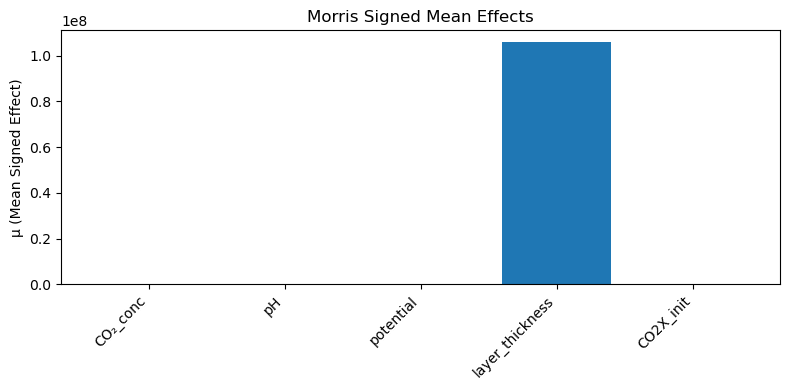

In [15]:
# MU BAR PLOT
plt.figure(figsize=(8,4))
plt.bar(param_names, Mu)
plt.ylabel("μ (Mean Signed Effect)")
plt.title("Morris Signed Mean Effects")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


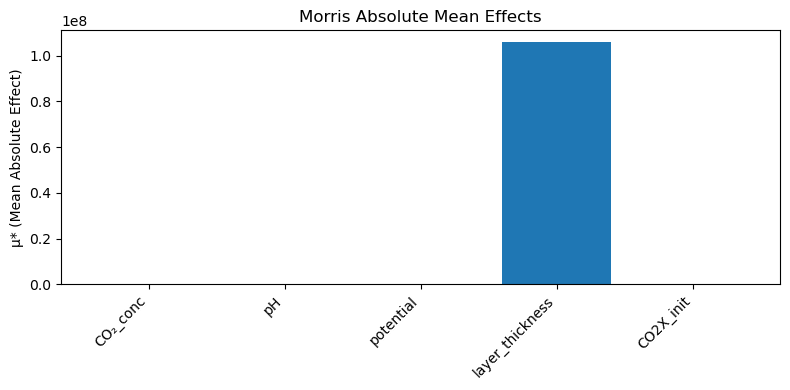

In [16]:
# MU* BAR PLOT
plt.figure(figsize=(8,4))
plt.bar(param_names, Mu_star)
plt.ylabel("μ* (Mean Absolute Effect)")
plt.title("Morris Absolute Mean Effects")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

sys:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


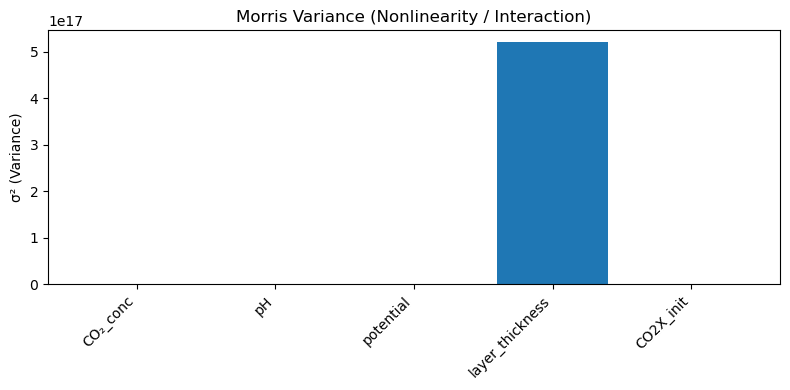

In [17]:
# VARIANCE BAR PLOT
plt.figure(figsize=(8,4))
plt.bar(param_names, sigma)
plt.ylabel("σ² (Variance)")
plt.title("Morris Variance (Nonlinearity / Interaction)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [18]:
using GlobalSensitivity
using Random

println("Running Sobol Global Sensitivity Analysis...")

sobol_result = gsa(run_co2_reduction_simulation, Sobol(), [[1e-5, 1e-2], [5.0, 9.0], [-0.714, -0.514], [1e-6, 1e-4], [0.5, 0.9]], samples = 32, batch = false)

Running Sobol Global Sensitivity Analysis...


┌ Warning: The `generate_design_matrices(n, d, sampler, R = NoRand(), num_mats)` method does not produces true and independent QMC matrices, see [this doc warning](https://docs.sciml.ai/QuasiMonteCarlo/stable/design_matrix/) for more context. 
│     Prefer using randomization methods such as `R = Shift()`, `R = MatousekScrambling()`, etc., see [documentation](https://docs.sciml.ai/QuasiMonteCarlo/stable/randomization/)
└ @ QuasiMonteCarlo ~/.julia/packages/QuasiMonteCarlo/KvLfb/src/RandomizedQuasiMonteCarlo/iterators.jl:255
[07:09:05] WARNING: not removing hydrogen atom without neighbors
[07:09:05] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate Stoke

  0.030972 seconds (8.46 k allocations: 7.893 MiB)
  1.530599 seconds (376.63 k allocations: 260.631 MiB, 47.60% gc time)


[07:09:18] WARNING: not removing hydrogen atom without neighbors
[07:09:18] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.015505 seconds (8.46 k allocations: 7.882 MiB, 62.05% gc time)
  0.181305 seconds (300.66 k allocations: 247.948 MiB, 4.00% gc time)


...

  0.004229 seconds (8.46 k allocations: 7.882 MiB)
  0.154368 seconds (263.59 k allocations: 217.383 MiB, 6.33% gc time)


[07:11:34] WARNING: not removing hydrogen atom without neighbors
[07:11:34] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004439 seconds (8.46 k allocations: 7.893 MiB)
  0.448790 seconds (447.99 k allocations: 321.046 MiB, 8.30% gc time)


[07:11:45] WARNING: not removing hydrogen atom without neighbors
[07:11:45] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

GlobalSensitivity.SobolResult{Vector{Float64}, Nothing, Nothing, Nothing}([0.12896538844501057, 0.015454184249627715, 0.12866710005954005, 0.6276803315988481, 0.011892813791278205], nothing, nothing, nothing, [0.129704390409357, 0.1796968392270654, 0.5295109240336133, 1.4614556649440142, 0.00026958038425641657], nothing)

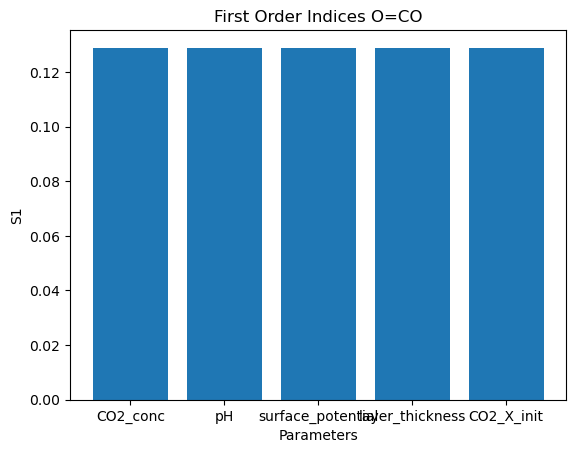

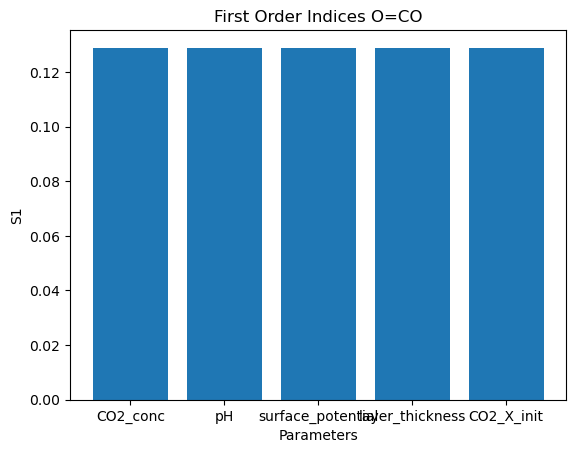

In [19]:
clf()

bar(
    ["CO2_conc", "pH", "surface_potential", "layer_thickness", "CO2_X_init"],
    sobol_result.S1[1, :]
)
title("First Order Indices O=CO")
xlabel("Parameters")
ylabel("S1")

gcf()


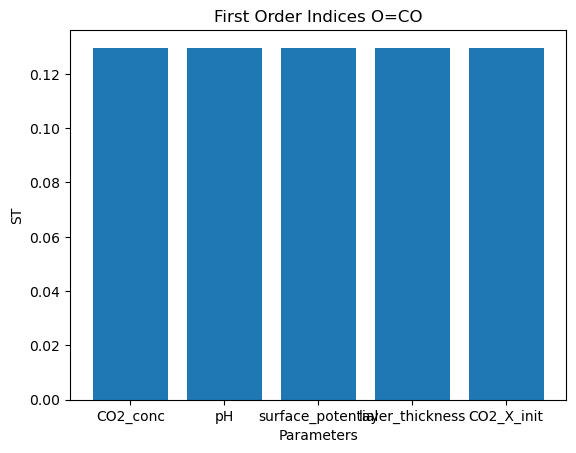

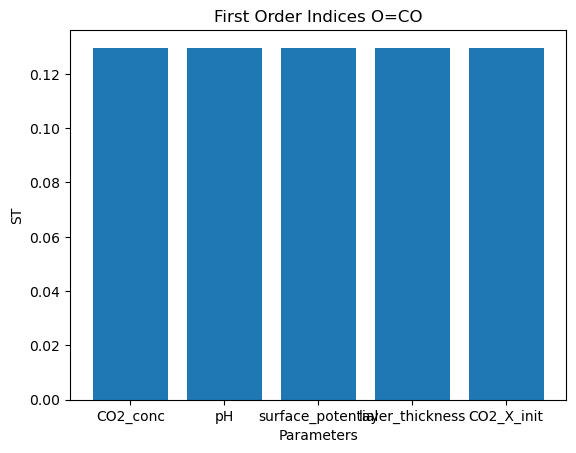

In [20]:
clf()

bar(
    ["CO2_conc", "pH", "surface_potential", "layer_thickness", "CO2_X_init"],
    sobol_result.ST[1, :]
)
title("First Order Indices O=CO")
xlabel("Parameters")
ylabel("ST")

gcf()


In [ ]:
using PythonPlot
using DifferentialEquations
using Sundials
using SciMLBase
using QuadGK
using DataFrames
using GlobalSensitivity
using Random
using Statistics

function run_co2_reduction_simulation(params::Vector{Float64})
	try
		CO2_M = params[1]
		pH = params[2]
		surface_phi = params[3]

		rms_file = "/home/danieltori/CO2_RR_RMG/CO2_Reduction_Ag/Ag_C2_042925.rms"

		outdict = readinput(rms_file)
		boundarylayerspcs = outdict["gas"]["Species"]
		boundarylayerrxns = outdict["gas"]["Reactions"]
		surfspcs = outdict["surface"]["Species"]
		surfrxns = outdict["surface"]["Reactions"]
		interfacerxns = outdict[Set(["surface", "gas"])]["Reactions"]
		solv = outdict["Solvents"][1]

		sitedensity = 2.292e-5; #Ag111
		boundarylayer = IdealDiluteSolution(boundarylayerspcs, boundarylayerrxns, solv,
			name = "boundarylayeruid", diffusionlimited = true)
		surf = IdealSurface(surfspcs, surfrxns, sitedensity, name = "surface")


    C_proton = 10.0^(-pH) * 1e3         # mol/m³
    C_co2    = CO2_M * 1e3              # mol/m³
    C_default = 1e-12
    V_res   = 1e3
		layer_thickness = 1e-6;
    AVratio = 36.0
    A_surf  = V_res * AVratio
    V_bl    = A_surf * layer_thickness
    sites   = sitedensity * A_surf
		

		initialcondsboundarylayer = Dict([
			"proton" => C_proton * V_bl,
			"CO2" => C_co2 * V_bl,
			"V" => V_bl,
			"T" => 300,
			"Phi" => 0.0,
			"d" => 0.0,
		])

		initialcondsreservoir = Dict([
			"proton" => C_proton,
			"CO2" => C_co2,
			"V" => V_res,
			"T" => 300,
		])

		initialcondssurf = Dict([
			"CO2X" => 0.6 * sites,
			"vacantX" => 0.4 * sites,
			"A" => A_surf,
			"T" => 300,
			"Phi" => surface_phi,
		])

		domainboundarylayer, y0boundarylayer, pboundarylayer = ConstantTVDomain(
			phase = boundarylayer, initialconds = initialcondsboundarylayer)
		domaincat, y0cat, pcat = ConstantTAPhiDomain(
			phase = surf, initialconds = initialcondssurf)

		inter, pinter = ReactiveInternalInterfaceConstantTPhi(
			domainboundarylayer, domaincat, interfacerxns, 298.15, A_surf)
		diffusionlayer = ConstantReservoirDiffusion(
			domainboundarylayer, initialcondsreservoir, A_surf, layer_thickness)
		interfaces = [inter, diffusionlayer]

		@time react, y0, p = Reactor((domainboundarylayer, domaincat),
			(y0boundarylayer, y0cat),
			(0.0, 1e3),
			interfaces,
			(pboundarylayer, pcat, pinter))

		@time sol = solve(react.ode, Sundials.CVODE_BDF(), abstol = 1e-20, reltol = 1e-8)

		if sol.retcode != :Success
			return [1e-15, 1e-15, 0.001, 0]
		end

		ssys = SystemSimulation(sol, (domainboundarylayer, domaincat), interfaces, p)

		# EXACT CALCULATION METHOD
		analysis_time = 100
		co2_rate = abs(sum(rops(ssys, "CO2", analysis_time)))

		OCO_rate = abs(sum(rops(ssys, "O=CO", analysis_time)))


		return [OCO_rate]

	catch e
		return [100]
	end
end

function run_gsa()
	bounds = [ [1e-5, 1e-2], [5, 9], [-0.714, -0.514]]
	param_names = ["CO2_conc", "pH", "surface_potential"]

	# Initialize variables
	morris_result = nothing

	# Morris
	println("Running Morris...")
	try
		morris_result = GlobalSensitivity.gsa(run_co2_reduction_simulation, GlobalSensitivity.Morris(), bounds; N = 200)
		println("Morris completed")
	catch e
		println("Morris failed: $e")
	end

	# Results
	if morris_result !== nothing
		num_outputs = size(morris_result.means_star, 1)
		num_params  = size(morris_result.means_star, 2)

		println("\nMorris Results:")
		for i in 1:num_outputs
			for j in 1:num_params
				#println("$(param_names[j]) -> Output $i: μ* = $(round(morris_result.means_star[i,j], digits=4))")
				println("Output $i  ←  $(param_names[j]) : μ* = $(round(morris_result.means_star[i,j], digits=4))")
			end
		end
	end

	return morris_result
end

morris_result = run_gsa()

Running Morris...


[12:03:51] WARNING: not removing hydrogen atom without neighbors
[12:03:51] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  6.159766 seconds (12.34 M allocations: 801.348 MiB, 5.95% gc time, 99.81% compilation time: <1% of which was recompilation)
  4.753560 seconds (5.03 M allocations: 537.622 MiB, 27.30% gc time, 82.57% compilation time)


[12:04:21] WARNING: not removing hydrogen atom without neighbors
[12:04:21] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004174 seconds (8.46 k allocations: 7.854 MiB)
  0.182023 seconds (315.07 k allocations: 269.788 MiB, 3.26% gc time)


...

  0.006309 seconds (8.46 k allocations: 7.893 MiB)
  0.307494 seconds (471.25 k allocations: 342.145 MiB, 4.55% gc time)


[12:07:12] WARNING: not removing hydrogen atom without neighbors
[12:07:12] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004106 seconds (8.46 k allocations: 7.893 MiB)
  0.262819 seconds (542.82 k allocations: 381.043 MiB, 4.63% gc time)


[12:07:22] WARNING: not removing hydrogen atom without neighbors
[12:07:22] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

GlobalSensitivity.MorrisResult{Matrix{Float64}, Vector{Any}}([8.925064637943782e-9 -1.3899141863843282e-11 -1.2522166905901307e-9], [8.925064637943782e-9 1.3899141863843282e-11 1.334848348042742e-9], [5.95883080929608e-16 4.599431502745591e-22 3.977143859880638e-18], Any[[[5.763587609083036e-10], [4.456685766442806e-14], [3.820874562678736e-12], [1.8051764857307104e-9], [8.206215718148618e-10], [4.1802028865451416e-9], [4.454674325222097e-9], [4.454674325222097e-9], [9.325004821347723e-8], [1.180764417831278e-10], [6.885850439912479e-9], [7.541750968325129e-9], [4.141800476521821e-10], [4.454250231992713e-10]], [[-4.81974207052769e-12], [-4.194794716749851e-12], [-4.194794716749851e-12], [-4.183056881056609e-12], [-4.318195311662602e-12], [-4.318195311662602e-12], [-9.58293418709386e-16], [-9.58293418709386e-16], [-1.0582213793555117e-15], [-1.0487068739528114e-15]  …  [-5.126868010820349e-11], [-5.126868010820349e-11], [-1.217503138847224e-12], [-1.2644865941453877e-12], [-1.264486594

In [ ]:
morris_result.means

1×3 Matrix{Float64}:
 8.92506e-9  -1.38991e-11  -1.25222e-9

In [ ]:
morris_result.variances

1×3 Matrix{Float64}:
 5.95883e-16  4.59943e-22  3.97714e-18

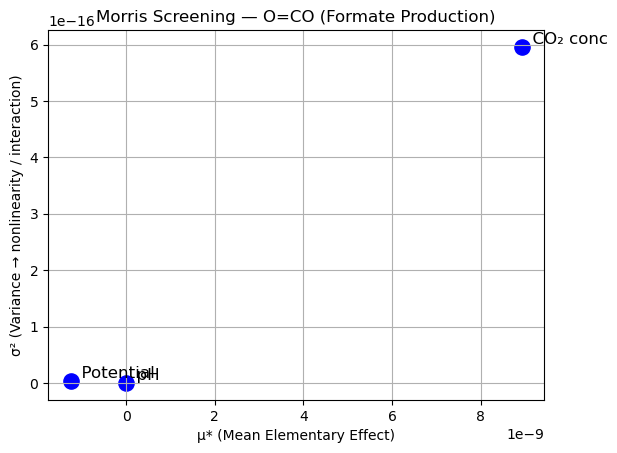

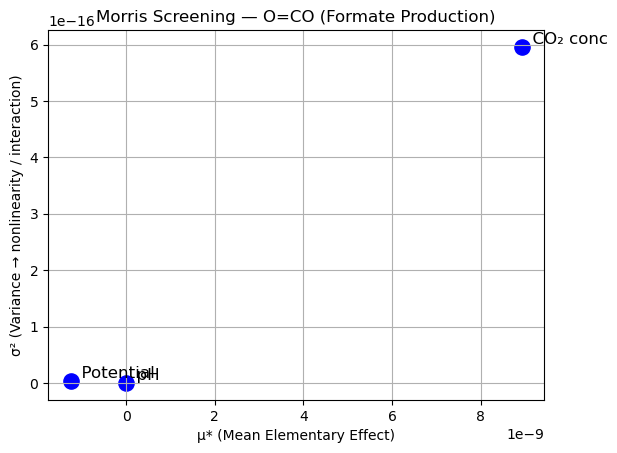

In [ ]:
# Extract Morris results for Output 1 (formate / O=CO)
xs = morris_result.means[1, :]       # μ*
ys = morris_result.variances[1, :]   # σ²

param_labels = ["CO₂ conc", "pH", "Potential"]   # your 3 parameters

# SCATTER PLOT
clf()
scatter(xs, ys, color="blue", s=120)

# LABEL EACH POINT
for i in 1:length(xs)
    text(xs[i], ys[i], "  $(param_labels[i])",
         fontsize=12, ha="left", va="bottom")
end

xlabel("μ* (Mean Elementary Effect)")
ylabel("σ² (Variance → nonlinearity / interaction)")
title("Morris Screening — O=CO (Formate Production)")
grid(true)
gcf()


In [ ]:
model_OCO(x) = run_co2_reduction_simulation(x)[1]

sobol_result = GlobalSensitivity.gsa(model_OCO, GlobalSensitivity.Sobol(), [[1e-5, 1e-2], [5, 9], [-0.714, -0.514]], samples = 32)

┌ Warning: The `generate_design_matrices(n, d, sampler, R = NoRand(), num_mats)` method does not produces true and independent QMC matrices, see [this doc warning](https://docs.sciml.ai/QuasiMonteCarlo/stable/design_matrix/) for more context. 
│     Prefer using randomization methods such as `R = Shift()`, `R = MatousekScrambling()`, etc., see [documentation](https://docs.sciml.ai/QuasiMonteCarlo/stable/randomization/)
└ @ QuasiMonteCarlo ~/.julia/packages/QuasiMonteCarlo/KvLfb/src/RandomizedQuasiMonteCarlo/iterators.jl:255
[12:54:20] WARNING: not removing hydrogen atom without neighbors
[12:54:20] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate Stoke

  0.008822 seconds (8.46 k allocations: 7.893 MiB)
  0.301437 seconds (444.66 k allocations: 326.170 MiB, 7.15% gc time)


[12:54:22] WARNING: not removing hydrogen atom without neighbors
[12:54:22] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004183 seconds (8.46 k allocations: 7.893 MiB)
  0.201144 seconds (346.94 k allocations: 286.847 MiB, 5.78% gc time)


[12:54:24] WARNING: not removing hydrogen atom without neighbors
[12:54:24] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

...

  0.004803 seconds (8.46 k allocations: 7.882 MiB)
  0.231367 seconds (339.97 k allocations: 281.986 MiB, 11.42% gc time)


[12:55:27] WARNING: not removing hydrogen atom without neighbors
[12:55:27] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004869 seconds (8.46 k allocations: 7.893 MiB)
  0.252459 seconds (430.69 k allocations: 322.858 MiB, 8.03% gc time)


[12:55:29] WARNING: not removing hydrogen atom without neighbors
[12:55:29] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

GlobalSensitivity.SobolResult{Vector{Float64}, Nothing, Nothing, Nothing}([0.09399881374602902, -0.06583338984566964, 1.204733827785305], nothing, nothing, nothing, [0.13215660772644378, 0.3981891963793615, 0.8854110028865866], nothing)

In [ ]:
Pkg.add("QuasiMonteCarlo")
using QuasiMonteCarlo

samples = 32
lb = [1e-5, 5, -0.714]
ub = [1e-2, 9, -0.514]
sampler = SobolSample()
A, B = QuasiMonteCarlo.generate_design_matrices(samples, lb, ub, sampler)

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
    Updating `~/miniforge3/envs/rmg_env3/julia_env/Project.toml`
  [8a4e6c94] + QuasiMonteCarlo v0.3.3
  No Changes to `~/miniforge3/envs/rmg_env3/julia_env/Manifest.toml`
Precompiling packages...
   1684.3 ms  ? DomainSets
   1983.8 ms  ? Symbolics
   4614.5 ms  ? ModelingToolkit
  21114.7 ms  ? SciMLSensitivity
   1827.3 ms  ? ReactionMechanismSimulator
┌ Warning: The `generate_design_matrices(n, d, sampler, R = NoRand(), num_mats)` method does not produces true and independent QMC matrices, see [this doc warning](https://docs.sciml.ai/QuasiMonteCarlo/stable/design_matrix/) for more context. 
│     Prefer using randomization methods such as `R = Shift()`, `R = MatousekScrambling()`, etc., see [documentation](https://docs.sciml.ai/QuasiMonteCarlo/stable/randomization/)
└ @ QuasiMonteCarlo ~/.julia/packages/QuasiMonteCarlo/KvLfb/src/RandomizedQuasiMonteCarlo/iterators.jl:255


2-element Vector{Matrix{Float64}}:
 [0.0004782812500000001 0.00547328125 … 0.00516109375 0.00016609375; 6.0625 8.0625 … 6.1875 8.1875; -0.573375 -0.673375 … -0.542125 -0.642125]
 [0.00547328125 0.0004782812500000001 … 0.00953171875 0.00453671875; 5.5625 7.5625 … 6.4375 8.4375; -0.529625 -0.629625 … -0.585875 -0.685875]

In [ ]:
model_OCO(x) = run_co2_reduction_simulation(x)[1]

sobol_result1 = GlobalSensitivity.gsa(model_OCO, GlobalSensitivity.Sobol(), A, B)

[13:26:47] WARNING: not removing hydrogen atom without neighbors
[13:26:47] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004621 seconds (8.46 k allocations: 7.893 MiB)
  0.258538 seconds (444.66 k allocations: 326.170 MiB, 8.75% gc time)


[13:26:49] WARNING: not removing hydrogen atom without neighbors
[13:26:49] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.005200 seconds (8.46 k allocations: 7.893 MiB)
  0.193868 seconds (346.94 k allocations: 286.847 MiB, 3.64% gc time)


[13:26:51] WARNING: not removing hydrogen atom without neighbors
[13:26:51] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

...

  0.003955 seconds (8.46 k allocations: 7.882 MiB)
  0.183984 seconds (339.97 k allocations: 281.986 MiB, 5.49% gc time)


[13:27:47] WARNING: not removing hydrogen atom without neighbors
[13:27:47] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.003922 seconds (8.46 k allocations: 7.893 MiB)
  0.247371 seconds (430.69 k allocations: 322.858 MiB, 16.41% gc time)


[13:27:49] WARNING: not removing hydrogen atom without neighbors
[13:27:49] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

GlobalSensitivity.SobolResult{Vector{Float64}, Nothing, Nothing, Nothing}([0.09399881374602902, -0.06583338984566964, 1.204733827785305], nothing, nothing, nothing, [0.13215660772644378, 0.3981891963793615, 0.8854110028865866], nothing)

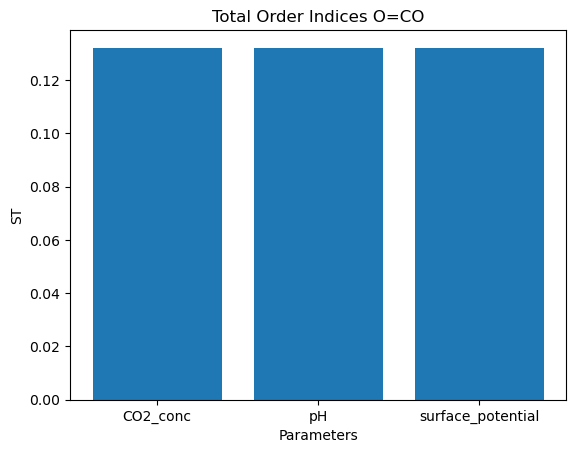

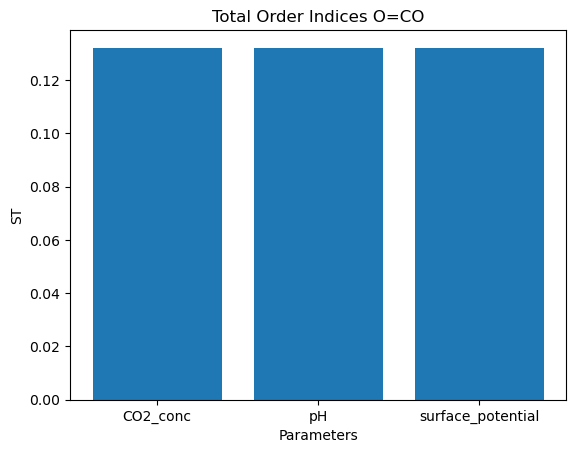

In [ ]:
clf()

bar(
    ["CO2_conc", "pH", "surface_potential"],
    sobol_result1.ST[1, :]
)
title("Total Order Indices O=CO")
xlabel("Parameters")
ylabel("ST")

gcf()

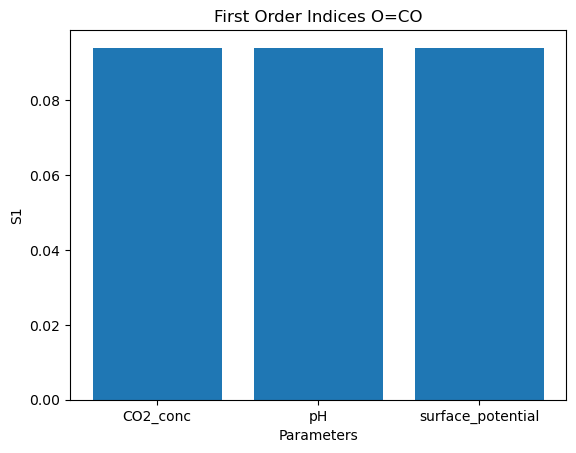

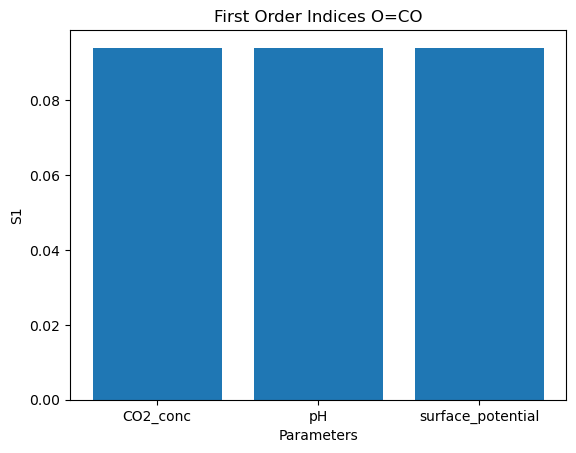

In [ ]:
clf()

bar(
    ["CO2_conc", "pH", "surface_potential"],
    sobol_result1.S1[1, :]
)
title("First Order Indices O=CO")
xlabel("Parameters")
ylabel("S1")

gcf()


In [ ]:
using PythonPlot
using DifferentialEquations
using Sundials
using SciMLBase
using QuadGK
using DataFrames
using Statistics

function run_co2_reduction_simulation(params::Vector{Float64})
	try
		CO2_M = params[1]
		pH = params[2]
		surface_phi = params[3]
		
		rms_file = "/home/danieltori/CO2_RR_RMG/CO2_Reduction_Ag/Ag_C2_042925.rms"

		outdict = readinput(rms_file)
		boundarylayerspcs = outdict["gas"]["Species"]
		boundarylayerrxns = outdict["gas"]["Reactions"]
		surfspcs = outdict["surface"]["Species"]
		surfrxns = outdict["surface"]["Reactions"]
		interfacerxns = outdict[Set(["surface", "gas"])]["Reactions"]
		solv = outdict["Solvents"][1]

		sitedensity = 2.292e-5; #Ag111
		boundarylayer = IdealDiluteSolution(boundarylayerspcs, boundarylayerrxns, solv,
			name = "boundarylayeruid", diffusionlimited = true)
		surf = IdealSurface(surfspcs, surfrxns, sitedensity, name = "surface")


    C_proton = 10.0^(-pH) * 1e3         # mol/m³
    C_co2    = CO2_M * 1e3              # mol/m³
    C_default = 1e-12
    V_res   = 1e3
    AVratio = 36.0
		layer_thickness = 1e-6
    A_surf  = V_res * AVratio
    V_bl    = A_surf * layer_thickness
    sites   = sitedensity * A_surf
		

		initialcondsboundarylayer = Dict([
			"proton" => C_proton * V_bl,
			"CO2" => C_co2 * V_bl,
			"V" => V_bl,
			"T" => 300,
			"Phi" => 0.0,
			"d" => 0.0,
		])

		initialcondsreservoir = Dict([
			"proton" => C_proton,
			"CO2" => C_co2,
			"V" => V_res,
			"T" => 300,
		])

		initialcondssurf = Dict([
			"CO2X" => 0.6 * sites,
			"vacantX" => 0.4 * sites,
			"A" => A_surf,
			"T" => 300,
			"Phi" => surface_phi,
		])

		domainboundarylayer, y0boundarylayer, pboundarylayer = ConstantTVDomain(
			phase = boundarylayer, initialconds = initialcondsboundarylayer)
		domaincat, y0cat, pcat = ConstantTAPhiDomain(
			phase = surf, initialconds = initialcondssurf)

		inter, pinter = ReactiveInternalInterfaceConstantTPhi(
			domainboundarylayer, domaincat, interfacerxns, 298.15, A_surf)
		diffusionlayer = ConstantReservoirDiffusion(
			domainboundarylayer, initialcondsreservoir, A_surf, layer_thickness)
		interfaces = [inter, diffusionlayer]

		@time react, y0, p = Reactor((domainboundarylayer, domaincat),
			(y0boundarylayer, y0cat),
			(0.0, 1e3),
			interfaces,
			(pboundarylayer, pcat, pinter))

		@time sol = solve(react.ode, Sundials.CVODE_BDF(), abstol = 1e-20, reltol = 1e-8)

		if sol.retcode != :Success
			return 1e-15
		end

		ssys = SystemSimulation(sol, (domainboundarylayer, domaincat), interfaces, p)

		# EXACT CALCULATION METHOD
		analysis_time = 100
		OCO_rate = abs(sum(rops(ssys, "O=CO", analysis_time)))
		
		return OCO_rate

	catch e
		return 1e-15
	end
end



run_co2_reduction_simulation (generic function with 1 method)

In [ ]:
using GlobalSensitivity
bounds = [
    [1e-5,   1e-2],      # CO2 concentration (mol/L)
    [5.0,    9.0],       # pH
    [-0.714, -0.514]     # Potential (V)
]

param_names = ["CO₂_conc", "pH", "potential"]

morris_method = Morris(
    p_steps = fill(4, 3),       # 4 levels, 3 parameters
    relative_scale = true,
    num_trajectory = 50,
    total_num_trajectory = 50,
    len_design_mat = 10
)

println("Running Morris Global Sensitivity Analysis...")

morris_result = gsa(
    run_co2_reduction_simulation,
    morris_method,
    bounds;
    batch = false
)


Running Morris Global Sensitivity Analysis...


[16:15:43] WARNING: not removing hydrogen atom without neighbors
[16:15:43] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.250136 seconds (8.46 k allocations: 7.893 MiB)
  2.376456 seconds (359.77 k allocations: 290.064 MiB, 1.80% gc time)


[16:15:53] WARNING: not removing hydrogen atom without neighbors
[16:15:53] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004498 seconds (8.46 k allocations: 7.893 MiB)
  0.517346 seconds (493.59 k allocations: 362.793 MiB, 4.54% gc time)


...

  0.004381 seconds (8.46 k allocations: 7.893 MiB)
  0.284807 seconds (501.27 k allocations: 364.665 MiB, 10.28% gc time)


[16:17:12] WARNING: not removing hydrogen atom without neighbors
[16:17:12] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.015872 seconds (8.46 k allocations: 7.893 MiB)
  0.314697 seconds (529.48 k allocations: 374.805 MiB, 4.67% gc time)


[16:17:15] WARNING: not removing hydrogen atom without neighbors
[16:17:15] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

GlobalSensitivity.MorrisResult{Matrix{Float64}, Vector{Any}}([95677.59092679355 46813.54238039977 160475.3817038612], [95724.57928326477 46813.9014987474 160491.1384253225], [1.1239174651451414e11 4.412975364476052e10 4.956420181623627e11], Any[[15.135677851599782, -32.09049615962405, -11.397985961186272, 8.886868630764538e-5, 16.79710081829518, 70.56404072801317, 4754.411588923075, 4754.411588923075, 66.16062789174369, 0.04127749696931133  …  -35.26141809, -25.720862526229247, -32.09049615962405, -300.2989785677082, -300.2989785677082, -300.2989785677082, -300.2989785677082, -39.73563680737663, -39.73563680737663, -300.2989785677082], [2.180449490124297, 1.109816367208283, 1.109816367208283, 1.109816367208283, 1.109816367208283, 2.180449490124297, 2.180449490124297, -0.5236565897809264, -0.06756141838312077, -0.06756141838312077  …  3.3714154896334074, -0.7492242487178855, 1.109816367208283, -0.2990191939155313, -0.07679383196169624, 0.760627551062864, -0.06756141838312077, -0.6694972

In [ ]:
miu_star = morris_result.means_star  
var     = morris_result.variances   

println("μ* (importance): ", miu_star)
println("σ² (nonlinearity/interaction): ", var)

In [ ]:
morris_result.means

2×3 Matrix{Float64}:
  2.28988e-8   2.1092e-11   -6.35517e-9
 -1.71807e-7  -6.34586e-10  -1.15052e-8

In [ ]:
morris_result.variances

2×3 Matrix{Float64}:
 2.27648e-15  4.38104e-21  2.65359e-16
 9.8151e-13   3.63127e-18  6.57855e-15

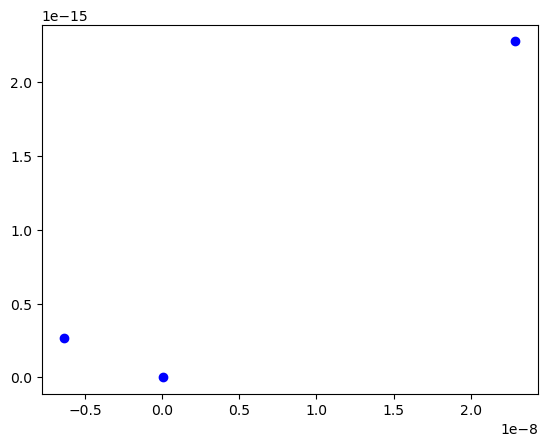

Python: <matplotlib.collections.PathCollection object at 0x7e5bf1a2a220>

In [ ]:
scatter(
    morris_result.means[1, :],
    morris_result.variances[1, :],
    color="blue"
)


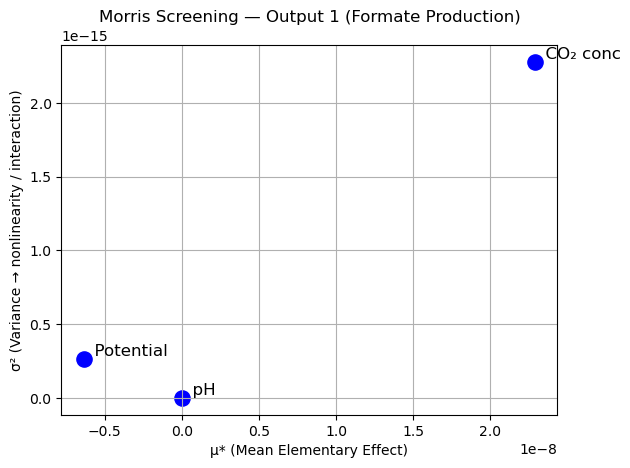

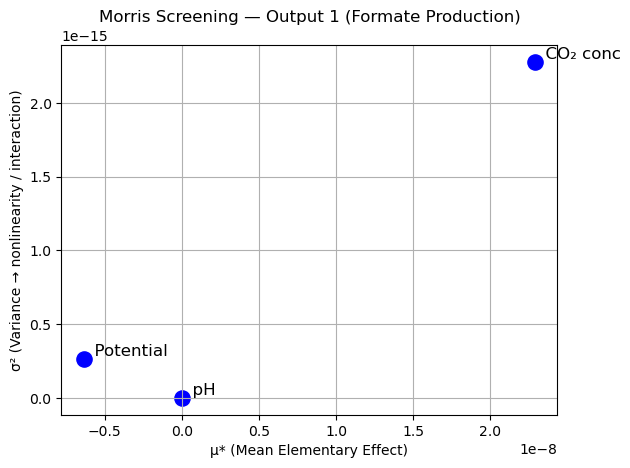

In [ ]:
# Extract Morris results for Output 1 (formate / O=CO)
xs = morris_result.means[1, :]       # μ*
ys = morris_result.variances[1, :]   # σ²

param_labels = ["CO₂ conc", "pH", "Potential"]   # your 3 parameters

# SCATTER PLOT
clf()
scatter(xs, ys, color="blue", s=120)

# LABEL EACH POINT
for i in 1:length(xs)
    text(xs[i], ys[i], "  $(param_labels[i])",
         fontsize=12, ha="left", va="bottom")
end

xlabel("μ* (Mean Elementary Effect)")
ylabel("σ² (Variance → nonlinearity / interaction)")
title("Morris Screening — Output 1 (Formate Production)")
grid(true)
gcf()


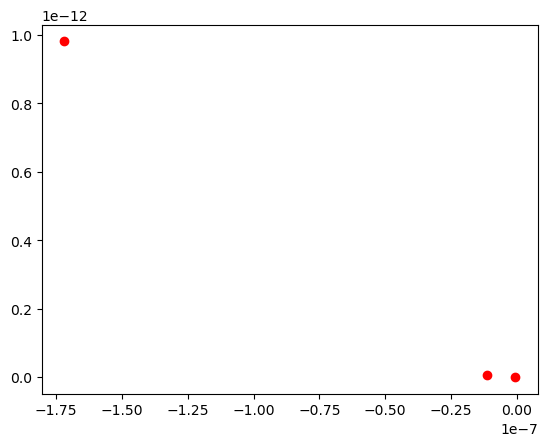

Python: <matplotlib.collections.PathCollection object at 0x7e5be0deff10>

In [ ]:
scatter(
    morris_result.means[2, :],
    morris_result.variances[2, :],
    color="red"
)

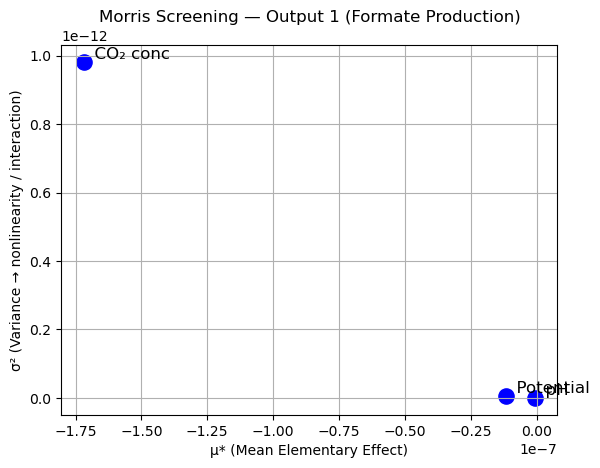

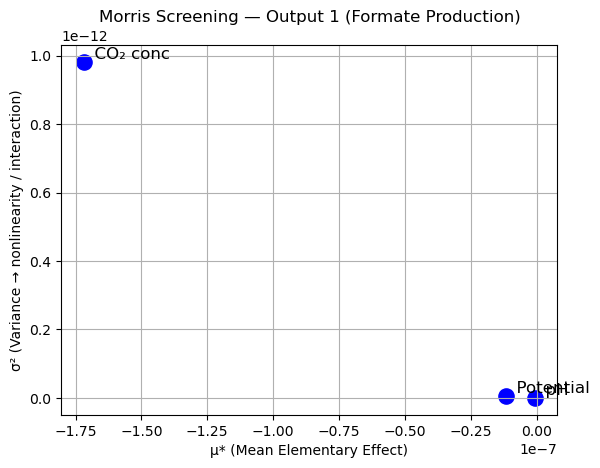

In [ ]:
# Extract Morris results for Output 1 (formate / O=CO)
xs = morris_result.means[2, :]       # μ*
ys = morris_result.variances[2, :]   # σ²

param_labels = ["CO₂ conc", "pH", "Potential"]   # your 3 parameters

# SCATTER PLOT
clf()
scatter(xs, ys, color="blue", s=120)

# LABEL EACH POINT
for i in 1:length(xs)
    text(xs[i], ys[i], "  $(param_labels[i])",
         fontsize=12, ha="left", va="bottom")
end

xlabel("μ* (Mean Elementary Effect)")
ylabel("σ² (Variance → nonlinearity / interaction)")
title("Morris Screening — Output 1 (Formate Production)")
grid(true)
gcf()


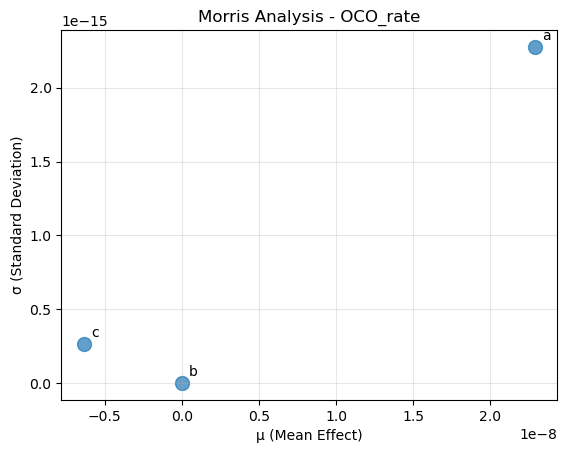

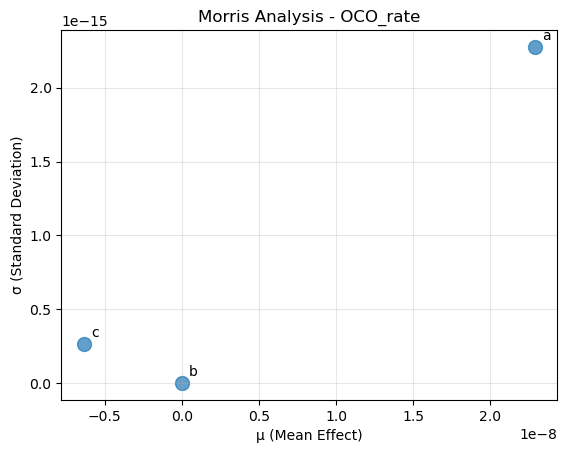

In [ ]:
# Correct plotting syntax for PythonPlot
param_labels = ["a", "b", "c"]

# Create Morris signature plot
scatter(morris_result.means[1, :], morris_result.variances[1, :], s = 100, alpha = 0.7)

# Add labels manually
for (i, label) in enumerate(param_labels)
	annotate(label, (morris_result.means[1, i], morris_result.variances[1, i]),
		xytext = (5, 5), textcoords = "offset points")
end

xlabel("μ (Mean Effect)")
ylabel("σ (Standard Deviation)")
title("Morris Analysis - OCO_rate")
grid(true, alpha = 0.3)
gcf()


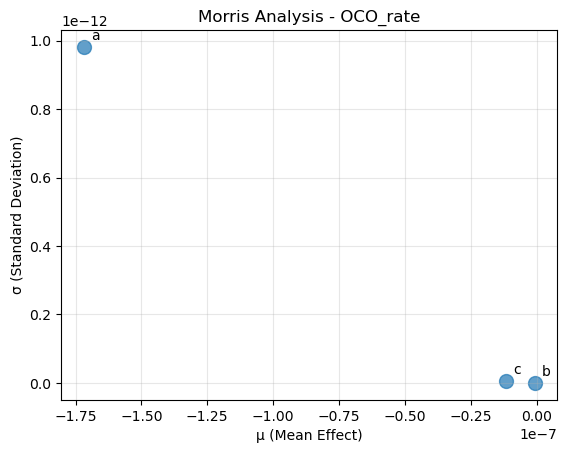

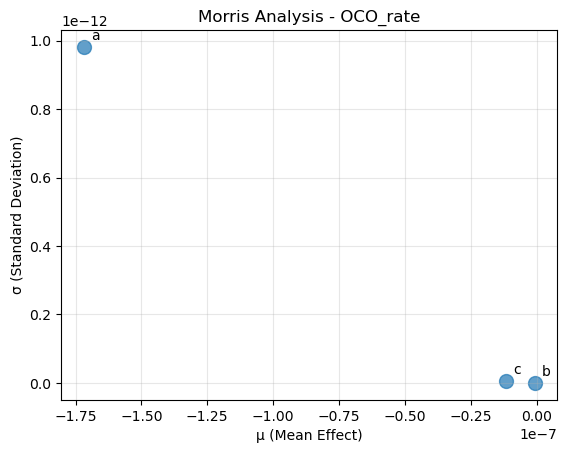

In [ ]:
# Correct plotting syntax for PythonPlot
param_labels = ["a", "b", "c"]

# Create Morris signature plot
scatter(morris_result.means[2, :], morris_result.variances[2, :], s = 100, alpha = 0.7)

# Add labels manually
for (i, label) in enumerate(param_labels)
	annotate(label, (morris_result.means[2, i], morris_result.variances[2, i]),
		xytext = (5, 5), textcoords = "offset points")
end

xlabel("μ (Mean Effect)")
ylabel("σ (Standard Deviation)")
title("Morris Analysis - OCO_rate")
grid(true, alpha = 0.3)
gcf()


In [ ]:
samples = 32
lb = [1e-5, 5.0, -0.714]
ub = [1e-2, 9.0, -0.514]
sampler = SobolSample()
A, B = QuasiMonteCarlo.generate_design_matrices(samples, lb, ub, sampler)

LoadError: UndefVarError: `SobolSample` not defined

In [ ]:
# Simple readable output for Morris results
param_names = ["CO2_conc", "pH", "surface_potential"]

println("MORRIS RESULTS FOR OCO_RATE:")
for (i, param) in enumerate(param_names)
	mu_star = abs(morris_result.means[1, i])
	sigma = morris_result.variances[1, i]
	importance = mu_star > 0.1 ? "HIGH" : (mu_star > 0.01 ? "MEDIUM" : "LOW")
	println("$param: μ* = $(round(mu_star, digits=6)) ($importance)")
end

MORRIS RESULTS FOR OCO_RATE:
CO2_conc: μ* = 0.0 (LOW)
pH: μ* = 0.0 (LOW)
surface_potential: μ* = 0.0 (LOW)



Running Sobol GSA...

--- Sobol for output 1: OCO_rate (formate) ---


┌ Warning: The `generate_design_matrices(n, d, sampler, R = NoRand(), num_mats)` method does not produces true and independent QMC matrices, see [this doc warning](https://docs.sciml.ai/QuasiMonteCarlo/stable/design_matrix/) for more context. 
│     Prefer using randomization methods such as `R = Shift()`, `R = MatousekScrambling()`, etc., see [documentation](https://docs.sciml.ai/QuasiMonteCarlo/stable/randomization/)
└ @ QuasiMonteCarlo ~/.julia/packages/QuasiMonteCarlo/KvLfb/src/RandomizedQuasiMonteCarlo/iterators.jl:255
[17:19:28] WARNING: not removing hydrogen atom without neighbors
[17:19:28] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate Stoke

  0.005553 seconds (8.46 k allocations: 7.893 MiB)
  0.268859 seconds (444.66 k allocations: 326.170 MiB, 4.21% gc time)


[17:19:32] WARNING: not removing hydrogen atom without neighbors
[17:19:32] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.003977 seconds (8.46 k allocations: 7.893 MiB)
  1.253427 seconds (346.94 k allocations: 286.847 MiB, 68.20% gc time)


...

[17:20:36] WARNING: not removing hydrogen atom without neighbors
[17:20:36] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004478 seconds (8.46 k allocations: 7.882 MiB)
  0.241683 seconds (339.97 k allocations: 281.986 MiB, 14.85% gc time)


[17:20:39] WARNING: not removing hydrogen atom without neighbors
[17:20:39] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

  0.004445 seconds (8.46 k allocations: 7.893 MiB)
  0.288652 seconds (430.69 k allocations: 322.858 MiB, 18.34% gc time)


[17:20:42] WARNING: not removing hydrogen atom without neighbors
[17:20:42] WARNING: not removing hydrogen atom without neighbors
┌ Warning: failed to generate StokesDiffusivity model for species vacantX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CHO2X
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species CO2HX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OCX
└ @ ReactionMechanismSimulator ~/ReactionMechanismSimulator.jl/src/Parse.jl:352
┌ Warning: failed to generate StokesDiffusivity model for species OX
└ @ ReactionMechanismSimulator ~/ReactionM

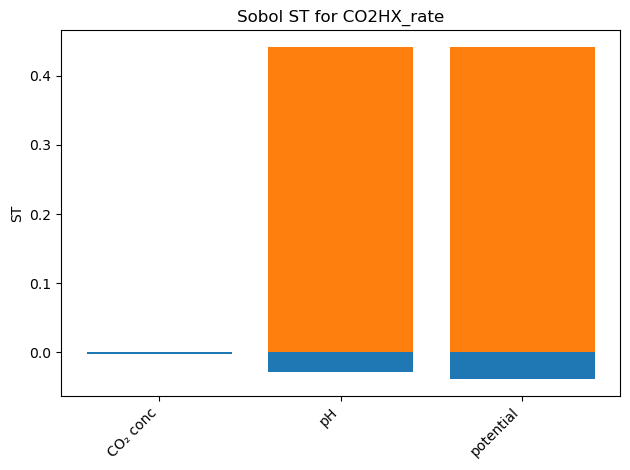

2-element Vector{Any}:
 GlobalSensitivity.SobolResult{Vector{Float64}, Nothing, Nothing, Nothing}([0.09399881374602902, -0.06583338984566964, 1.204733827785305], nothing, nothing, nothing, [0.13215660772644378, 0.3981891963793615, 0.8854110028865866], nothing)
 GlobalSensitivity.SobolResult{Vector{Float64}, Nothing, Nothing, Nothing}([-0.0023437164001431513, -0.02827495260626911, -0.03865280657810527], nothing, nothing, nothing, [0.0011847389416517905, 0.44169625649436695, 0.44159021482696165], nothing)

In [ ]:
# SOBOL GLOBAL SENSITIVITY ANALYSIS
function run_sobol_gsa()

    bounds = [
        [1e-5, 1e-2],      # CO₂ concentration (mol/L)
        [5.0, 9.0],        # pH
        [-0.714, -0.514]   # potential (V)
    ]

    param_names  = ["CO₂ conc", "pH", "potential"]
    output_names = ["OCO_rate (formate)", "CO2HX_rate"]

    sobol_results = Vector{Any}(undef, length(output_names))

    Random.seed!(1234)
    nsamples = 32    

    println("\nRunning Sobol GSA...")

    for k in 1:length(output_names)

        println("\n--- Sobol for output $k: $(output_names[k]) ---")

        # Scalar model wrapper
        model_k(x) = run_co2_reduction_simulation(x)[k]

        # Run Sobol (S1 and ST always computed)
        sob = GlobalSensitivity.gsa(
            model_k,
            GlobalSensitivity.Sobol(),
            bounds;
            samples = nsamples
        )

        sobol_results[k] = sob

        S1 = sob.S1
        ST = sob.ST
        S2 = sob.S2   # often nothing

        # PRINT RESULTS 
        println("\nFirst-order S1:")
        for j in 1:length(param_names)
            println("  $(param_names[j]) : S1 = $(round(S1[j], digits=4))")
        end

        println("\nTotal-order ST:")
        for j in 1:length(param_names)
            println("  $(param_names[j]) : ST = $(round(ST[j], digits=4))")
        end

        # PLOT S1
        clf()
        bar(1:length(S1), S1)
        xticks(1:length(param_names), param_names, rotation=45, ha="right")
        ylabel("S1")
        title("Sobol S1 for $(output_names[k])")
        tight_layout()
        gcf()

        # PLOT ST 
        bar(1:length(ST), ST)
        xticks(1:length(param_names), param_names, rotation=45, ha="right")
        ylabel("ST")
        title("Sobol ST for $(output_names[k])")
        tight_layout()
        gcf()

        # OPTIONAL S₂
        if S2 !== nothing
            S2_plot = deepcopy(S2)
            for i in 1:size(S2_plot, 1)
                S2_plot[i,i] = 0.0
            end

            clf()
            imshow(
                S2_plot,
                origin="lower",
                aspect="equal"
            )
            colorbar()
            xticks(1:length(param_names), param_names, rotation=45)
            yticks(1:length(param_names), param_names)
            title("Sobol S2 interactions for $(output_names[k])")
            tight_layout()
            gcf()
        else
            println("\n[S2 unavailable — interactions cannot be computed with current sample size.]")
        end
    end

    return sobol_results
end

sobol_results = run_sobol_gsa()
